## Exercise Resampling methods      
**Name:** Jenny Laberg Nilsson      
**Course:** BERN02  
**Date:** 1th of October

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import degrees
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
import scipy.optimize as opt

## Cross validation


1. Load the data

In [2]:
df = pd.read_csv('data/pollution_cleaneddata.csv')
df.head()

,PREC,JANT,JULT,OVR65,POPN,EDUC,HOUS,DENS,NONW,WWDRK,POOR,HC,NOX,SO@,HUMID,MORT
0,36.0,27.0,71.0,8.1,3.34,11.4,81.5,3243.0,8.8,42.6,11.7,21.0,15.0,59.0,59.0,921.870
1,35.0,23.0,72.0,11.1,3.14,11.0,78.8,4281.0,3.5,50.7,14.4,8.0,10.0,39.0,57.0,997.875
2,44.0,29.0,74.0,10.4,3.21,9.8,81.6,4260.0,0.8,39.4,12.4,6.0,6.0,33.0,54.0,962.354
3,47.0,45.0,79.0,6.5,3.41,11.1,77.5,3125.0,27.1,50.2,20.6,18.0,8.0,24.0,56.0,982.291
4,43.0,35.0,77.0,7.6,3.44,9.6,84.6,6441.0,24.4,43.7,14.3,43.0,38.0,206.0,55.0,1071.289


2. Specify a polynomial regression model with degree p that predicts mortality as a function of the average July temperature in degrees F.

In [3]:
# Selecting features (X) and target (y)
X = df[["JULT"]]  # Average July temperature (°F)
y = df["MORT"]  # Total age-adjusted mortality rate

In [4]:
def polynomial_regression(degree_p):
    # Create a polynomial model of degree p
    # y = beta_0 + beta_1*x + beta_2*x^2 + ... + beta_p*x^p
    model = make_pipeline(PolynomialFeatures(degree_p, include_bias=True), LinearRegression())
    return model

In [5]:
p = 4 # selected degree of polynomial regression
# Instantiate and fit the model
model = polynomial_regression(p)
model.fit(X, y)
# extract the polynomial features and linear regression steps
poly_features = model.named_steps["polynomialfeatures"]
linear_reg = model.named_steps["linearregression"]

print(f"Intercept (beta_0): {linear_reg.intercept_}")
print(f"Coefficients (beta_1 to beta_{p}): {linear_reg.coef_[1:]}")

Intercept (beta_0): 212.0590475372876
Coefficients (beta_1 to beta_4): [ 1.14092231e-06  1.12767937e-04  6.29023245e-03 -6.03758522e-05]


## Validation set approach

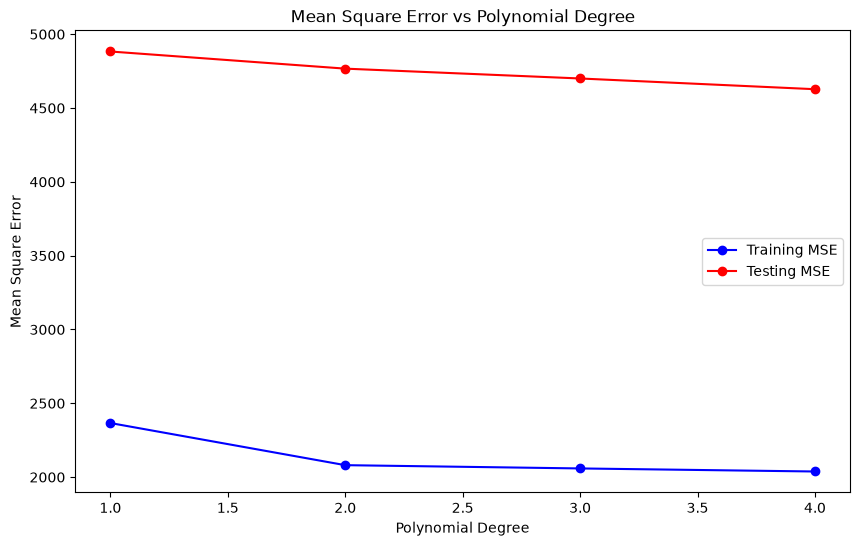

In [6]:
# 1. Set random seed for reproducibility
np.random.seed(42)

# 2. Split the data into training and testing sets (50% train, 50% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Evaluate MSE for degrees 1 to 4
parameters = [1, 2, 3, 4]
train_mse = []
test_mse = []

# 3. For polynomial models with degree 1 up to 4, derive the mean square error of prediction for the training and testing data sets, respectively. Note: It is ok to use built in functions for polynomial regression.
for degree in parameters:
    # Build polynomial model pipeline
    model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=True), LinearRegression())
    # Fit on training data
    model.fit(X_train, y_train)
    # Calculate MSE for training and testing sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))

# 4. Present the results in a plot with polynomial degree on the x-axis and Mean Square Error on the y-axis (example provided below).
plt.figure(figsize=(10, 6))
plt.plot(parameters, train_mse, marker='o', label='Training MSE', color='blue')
plt.plot(parameters, test_mse, marker='o', label='Testing MSE', color='red')
plt.title('Mean Square Error vs Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Square Error')
plt.legend()
plt.show()


5. Judging from the graph you just generated, which degree of the polynomial would you recommend if the goal is to have a small variance of new predictions.
Answer:     
I would recommend Degree 1 (linear). Lower-degree polynomials are less flexible, making their estimates more stable and less sensitive to small fluctuations or noise in the training set. At the same time, as seen in the graph, increasing the polynomial degree to $p = 3$ or $p = 4$ yields minimal improvement in test MSE.

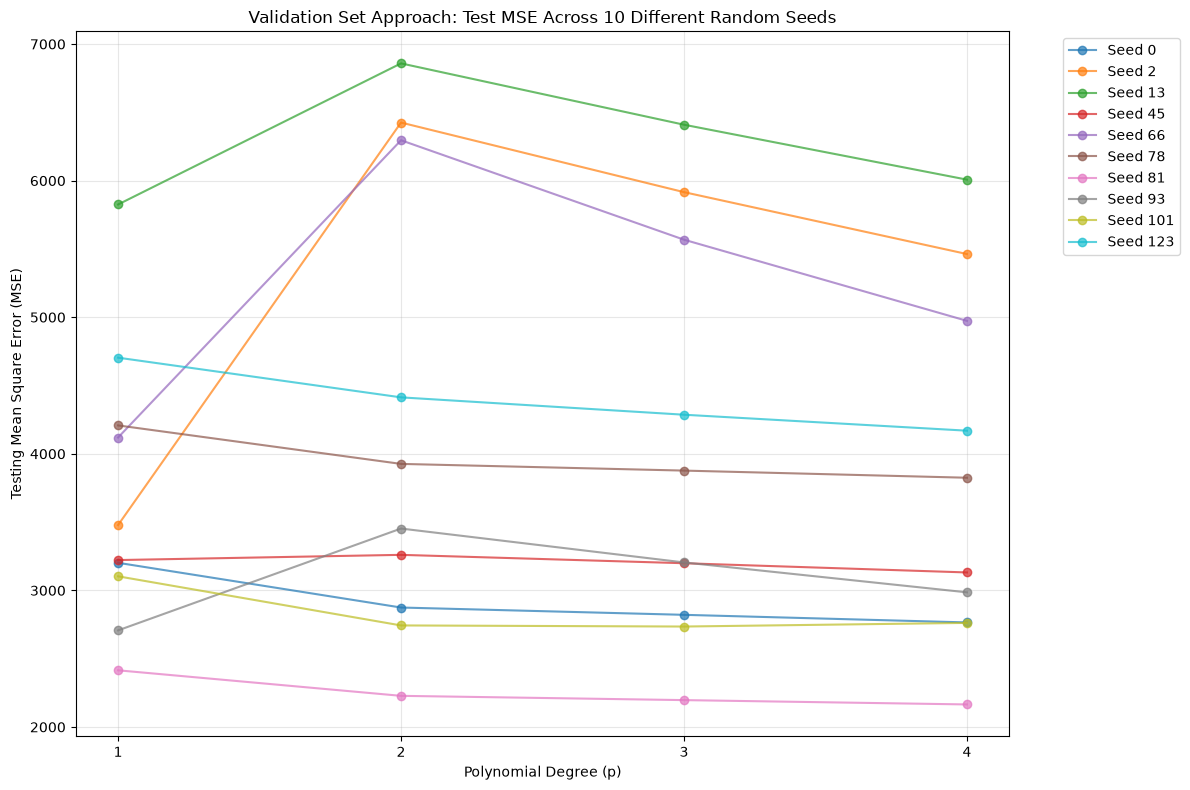

In [7]:
# List of 10 distinct random seeds
seeds = [0, 2, 13, 45, 66, 78, 81, 93, 101, 123]
parameters = [1, 2, 3, 4]  # Polynomial degrees to evaluate
plt.figure(figsize=(12, 8))

# 5. For each of the 10 random seeds, repeat the above procedure and plot the results in a single plot. Use different colors for each random seed and include a legend.
for seed in seeds:
    np.random.seed(seed)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=seed)
    
    train_mse = []
    test_mse = []

    # Fit models of degree 1 to 4 and compute test MSE
    for p in parameters:
        model = make_pipeline(PolynomialFeatures(degree=p, include_bias=True), LinearRegression())
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_mse.append(mean_squared_error(y_train, y_train_pred))
        test_mse.append(mean_squared_error(y_test, y_test_pred))
    
    plt.plot(parameters, test_mse, marker='o', alpha=0.7, label=f'Seed {seed}')
    plt.title("Validation Set Approach: Test MSE Across 10 Different Random Seeds")
    plt.xticks(parameters)
    plt.xlabel('Polynomial Degree (p)')
    plt.ylabel("Testing Mean Square Error (MSE)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
plt.show()

6. Repeat the procedure ten times but with other random seeds. Do you get similar results for other seeds?      
Answer:     
No, the results are not similar across different seeds. The test MSE curves vary substantially depending on the random split chosen.

## K-fold cross-validation

7. Select a polynomial degree, e.g. p=2. Estimate the variance of predictions using the K-fold cross-validation approach where you hold out K=3 sets.

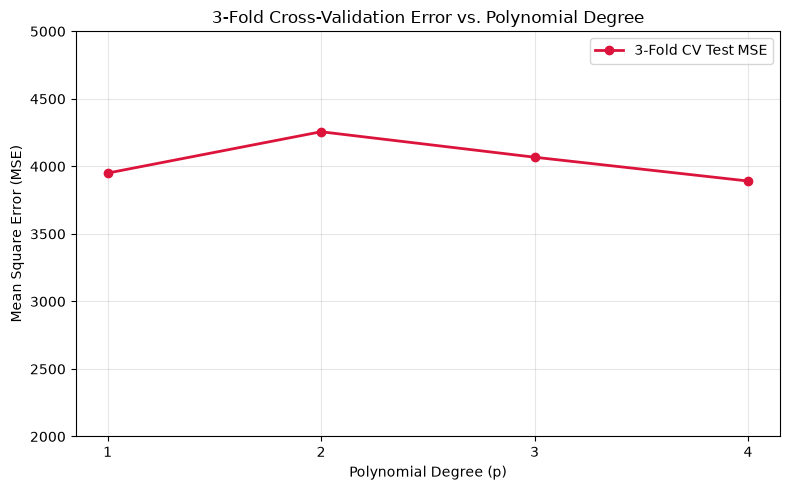

=== Results for Polynomial Degree p = 2 ===
Average RMSE across 3 folds: 65.24
Variance of CV MSE across folds: 1044323.25
Variance of Predictions: 1670.88

     Actual   Predicted    Residual
0   921.870  938.942616  -17.072616
1   997.875  935.478956   62.396044
2   962.354  956.040622    6.313378
3   982.291  949.532864   32.758136
4  1071.289  952.697754  118.591246


In [8]:
# select a degree for polynomial regression 
p = [1, 2, 3, 4]  # You can choose any degree from this list
# build polynomial model with new degree
new_model = polynomial_regression(p)
# set up seed and K-Fold cross-validation with 3 folds
k = 3
seed = 42
kf = KFold(n_splits=k, shuffle=True, random_state=seed)
cv_test_mse = []
# Dictionary to hold out-of-fold metrics for each degree
degree_results = {}

for p in parameters:
    new_model = polynomial_regression(p)
    fold_mses = []
    oof_predictions = np.zeros(len(y))  # Initialize out-of-fold predictions array
    for train_index, val_index in kf.split(X):
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
        # Fit the model on the training fold
        new_model.fit(X_train_fold, y_train_fold)
        # Predict on the validation fold
        y_val_pred = new_model.predict(X_val_fold)
        # Calculate MSE for the current fold
        fold_mse = mean_squared_error(y_val_fold, y_val_pred)
        fold_mses.append(fold_mse)
        # Store out-of-fold predictions
        oof_predictions[val_index] = y_val_pred
    # Record mean CV MSE for this degree
    avg_cv_mse = np.mean(fold_mses)
    cv_test_mse.append(avg_cv_mse)
    # Save detailed stats for reporting
    degree_results[p] = {"fold_mses": fold_mses, "rmse": np.sqrt(avg_cv_mse),"fold_var": np.var(fold_mses, ddof=1),"pred_var": np.var(oof_predictions, ddof=1),"oof_df": pd.DataFrame({"Actual": y,"Predicted": oof_predictions,"Residual": y - oof_predictions,})}

plt.figure(figsize=(8, 5))
plt.plot(parameters, cv_test_mse, marker="o", color="crimson", linewidth=2, label="3-Fold CV Test MSE")
plt.xticks(parameters)
plt.xlabel("Polynomial Degree (p)")
plt.ylabel("Mean Square Error (MSE)")
plt.title("3-Fold Cross-Validation Error vs. Polynomial Degree")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(2000, 5000)
plt.tight_layout()
plt.show()

# print metrics for a specific degree (e.g., p = 2 or p = 4)
chosen_p = 2  # Change to 4 if required by your prompt
res = degree_results[chosen_p]

print(f"=== Results for Polynomial Degree p = {chosen_p} ===")
print(f"Average RMSE across {k} folds: {res['rmse']:.2f}")
print(f"Variance of CV MSE across folds: {res['fold_var']:.2f}")
print(f"Variance of Predictions: {res['pred_var']:.2f}\n")
print(res["oof_df"].head())

Comment:   
This model uses 3-fold cross-validation with polynomial degrees p = [1, 2, 3, 4], the overall Root Mean Squared Error (RMSE) is approximately 65. This means that the model's predictions miss the actual mortality rate by roughly 65 deaths per 100,000 on average.      
Comment:    
Prediction Variability: The variance of the out-of-fold predictions is approx. 1,671, this indicates how the model's predicted mortality rates vary on average.    
Individual Performance: Examining specific out-of-fold predictions shows strong local fits for certain data points (e.g., Row 2 with a residual of 6), while others show larger deviations (e.g., Row 4 with a residual of 118).

8. Repeat the procedure ten times but with other random seeds.

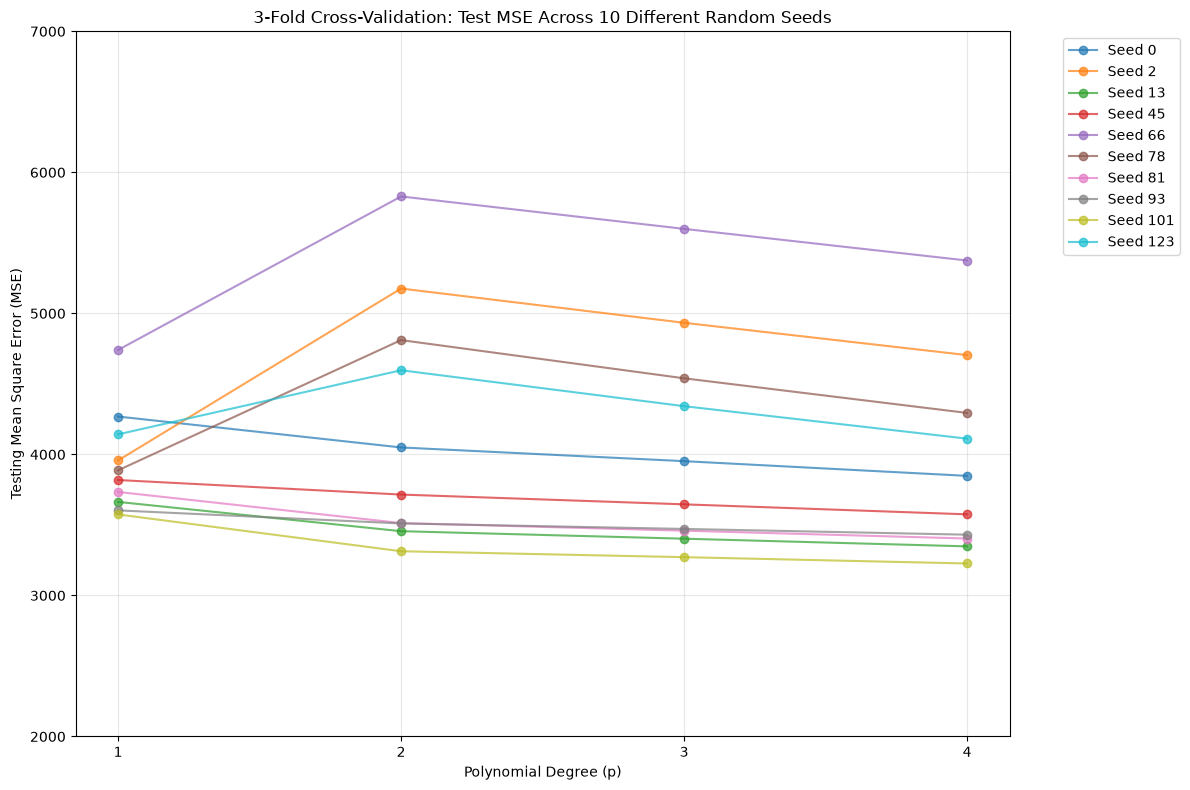

In [9]:
seeds = [0, 2, 13, 45, 66, 78, 81, 93, 101, 123]
parameters = [1, 2, 3, 4]
k = 3
plt.figure(figsize=(12, 8))

for seed in seeds: # loop through each random seed
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    cv_mses_for_seed = []

    for p in parameters:
        fold_mses = []
        
        for train_index, val_index in kf.split(X):
            X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
            y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
            # Fit the model on the training fold
            model = polynomial_regression(p)
            model.fit(X_train_fold, y_train_fold)
            # Predict on the validation fold
            y_val_pred = model.predict(X_val_fold)
            # Calculate MSE for the current fold
            fold_mse = mean_squared_error(y_val_fold, y_val_pred)
            fold_mses.append(fold_mse)
            # Store out-of-fold predictions
            oof_predictions[val_index] = y_val_pred

        # Average MSE across the 3 folds for this specific degree
        cv_mses_for_seed.append(np.mean(fold_mses))

    # Plotting the results for this seed
    plt.plot(parameters, cv_mses_for_seed, marker='o', alpha=0.7, label=f'Seed {seed}')

# Matching formatting and styling
plt.xticks(parameters)
plt.xlabel("Polynomial Degree (p)")
plt.ylim(2000, 7000) # Adjust y-axis limits for better comparison
plt.ylabel("Testing Mean Square Error (MSE)")
plt.title("3-Fold Cross-Validation: Test MSE Across 10 Different Random Seeds")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Do you get similar results for other seeds? If so, why?     
Yes, after adjusting the y axis for better comparison I can see that we get significantly more similar and stable results across different seeds compared to the Validation Set Approach. All though seed-dependent variance remains.

## The Bootstrap

In [10]:
df_bird_count = pd.read_csv('data/bird_count.csv')
bird_df_sorted = df_bird_count.sort_values(by='yr')
bird_df_sorted.head()

,count,yr,observerAge,lineCov
10,10,1999,27,0.991667
6,5,2000,28,0.991667
11,9,2001,29,0.991667
2,12,2002,30,0.991667
9,14,2004,58,1.000000


9. Retrieve the Poisson model fitted with maximum likelihood that you did earlier in the course.

In [11]:
# function for poisson regression
def predict_lambda(beta, x):
    """
    Find the estimated rate (lambda) by computing: 
    lambda = e^(X_i^T*Beta) 
    """
    beta_0 = beta[0]
    beta_1 = beta[1]
    
    return(np.exp(beta_0 + beta_1 * x))

def maximum_likelihood_estimation(beta, x, y):
    """
    Computes log-likelihood for Poisson regression.
    """
    # get the lambda (estimated rate) by calling the function
    lambda_i = predict_lambda(beta, x)

    # compute the Log-Likelihood function 
    log_likelihood = np.sum(y * np.log(lambda_i) - lambda_i)
    # return negative log-likelihood since scipy.optimize.minimize performs minimization
    
    return -log_likelihood

def optimize_parameters(beta, x, y):
    # use built in function for optimizing of parameters using scipy.optimize.minimize
    fit_result = opt.minimize(maximum_likelihood_estimation, beta, args=(x, y))

    # extract optimal parameters
    beta_hat = fit_result.x
    
    return(beta_hat)

10. Use the bootstrap to approximate the standard error of the estimate of the slope parameter. When Ullrika takes the standard deviation of the bootstrap sample of the slope parameter she get 0.034212. What do I get?

In [12]:
# bootstrap Setup 
initial_beta = [0.0, 0.0]
np.random.seed(42)  
B = 1000  
bootstrap_beta1_estimates = []

# extract values into NumPy arrays
x = bird_df_sorted['yr'].values
x = x - x.min()  # Center the years to start from 0
y = bird_df_sorted['count'].values
n_samples = len(y)

# bootstrap Loop
for i in range(B):
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    x_boot = x[boot_indices]
    y_boot = y[boot_indices]

    beta_hat_boot = optimize_parameters(initial_beta, x_boot, y_boot)
    bootstrap_beta1_estimates.append(beta_hat_boot[1])


# Compute standard error
se_beta1 = np.std(bootstrap_beta1_estimates, ddof=1)
print(f"Bootstrap Standard Error of Beta_1: {se_beta1:.6f}")
print(f"Ullrikas Standard Error of Beta_1: 0.034212") 
print(f"First Bootstrap parameter estimates for Beta_1: {float(bootstrap_beta1_estimates[0])}")  # Display only the first estimate for comparison
print(f"Ullrikas Bootstrap Estimates of Beta_1: -0.03244")

Bootstrap Standard Error of Beta_1: 0.033098
Ullrikas Standard Error of Beta_1: 0.034212
First Bootstrap parameter estimates for Beta_1: -0.03716866897615187
Ullrikas Bootstrap Estimates of Beta_1: -0.03244
